<a href="https://colab.research.google.com/github/vaishnavi-08-reddy/growfinix_intenship/blob/main/task4_Movie_Review_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import string
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from transformers import pipeline
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import files

# Download necessary text datasets for NLTK
nltk.download('stopwords', quiet=True)

print("Loading Hugging Face Transformer Model")
# Task 4 Bonus Point: Advanced Transformer-based Sentiment Analysis
# Using a highly-optimized model for quick execution in Colab
hf_classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)
print("Setup complete and model ready")

Loading Hugging Face Transformer Model


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Setup complete and model ready


In [ ]:
print("👇 Please upload your 'IMDB Dataset.csv' file:")
uploaded = files.upload()

👇 Please upload your 'IMDB Dataset.csv' file:


Saving IMDB Dataset.csv.zip to IMDB Dataset.csv.zip


In [ ]:
file_name = list(uploaded.keys())[0]

Cleaning review text data...
Generating Word Cloud...


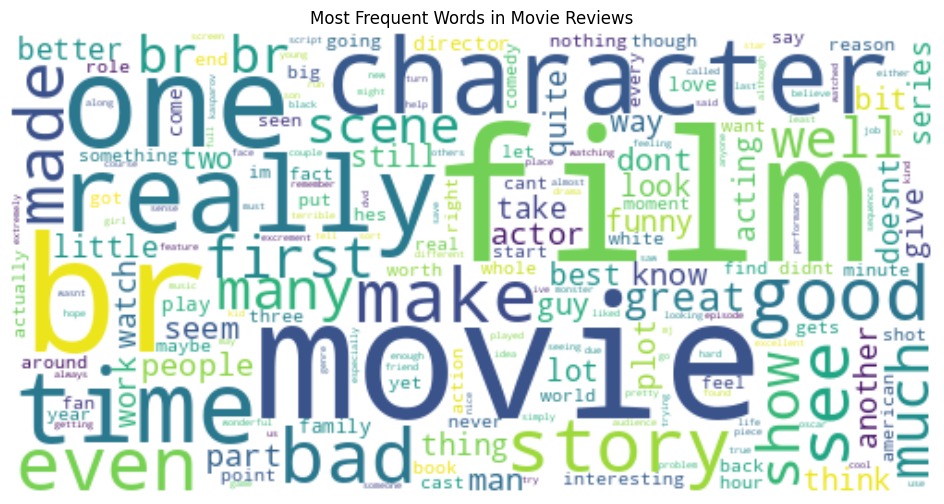

🤖 Analyzing sentiments (this may take a minute)...

📊 Generating Accuracy Heatmap...

📋 Classification Report:
              precision    recall  f1-score   support

         Neg       0.72      0.84      0.78        56
         Pos       0.74      0.59      0.66        44

    accuracy                           0.73       100
   macro avg       0.73      0.72      0.72       100
weighted avg       0.73      0.73      0.72       100



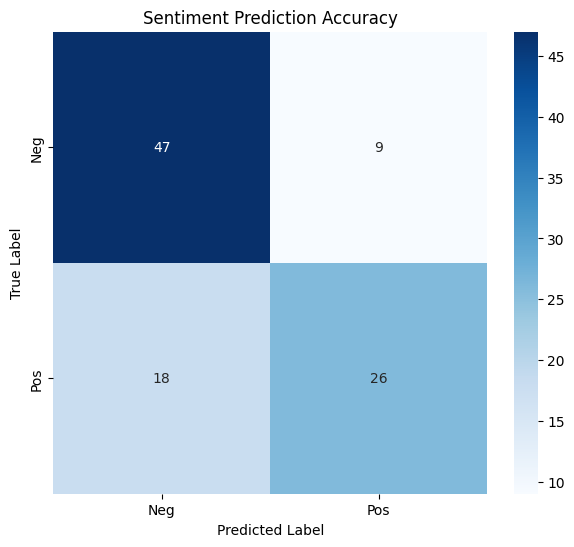

In [ ]:
df = pd.read_csv(io.BytesIO(uploaded[file_name]), compression='zip')

# Sample 100 rows for faster processing on Colab CPU/GPU environment
df = df.sample(n=100, random_state=42).reset_index(drop=True)

#Text Cleaning Function
stop_words = set(stopwords.words('english'))

def clean_movie_review(text):
    text = text.lower() # Lowercasing
    text = text.translate(str.maketrans('', '', string.punctuation)) # Punctuation removal
    text = ' '.join([word for word in text.split() if word not in stop_words]) # Stopword removal
    return text

print("Cleaning review text data...")
df['cleaned_review'] = df['review'].apply(clean_movie_review)
# === WORD CLOUD OF MOST FREQUENT WORDS ===

print("Generating Word Cloud...")

all_words = " ".join(df['cleaned_review'])

wordcloud = WordCloud(
    width=500,
    height=250,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Movie Reviews")

# Save image
plt.savefig("wordcloud_reviews.png", dpi=300, bbox_inches='tight')

plt.show()

# Sentiment Analysis with TextBlob and Transformers
print("🤖 Analyzing sentiments (this may take a minute)...")
tb_polarities = []
tb_labels = []
hf_labels = []

for review in df['cleaned_review']:
    # Rule-Based: TextBlob Polarity
    blob = TextBlob(review)
    polarity = blob.sentiment.polarity
    tb_polarities.append(polarity)

    if polarity > 0.1:
        tb_labels.append('Positive')
    elif polarity < -0.1:
        tb_labels.append('Negative')
    else:
        tb_labels.append('Neutral')

    # Deep Learning: Hugging Face Transformer (Truncated to fit model constraint token sizes)
    shortened_review = " ".join(review.split()[:300])
    transformer_res = hf_classifier(shortened_review)[0]
    hf_labels.append(transformer_res['label'].title())

# Add new columns with sentiment labels
df['textblob_polarity'] = tb_polarities
df['TextBlob_Sentiment'] = tb_labels
df['Transformer_Sentiment'] = hf_labels
# === SENTIMENT PREDICTION ACCURACY HEATMAP ===

print("\n📊 Generating Accuracy Heatmap...")

# Convert labels into short form
true_labels = []
predicted_labels = []

for tb, hf in zip(df['TextBlob_Sentiment'], df['Transformer_Sentiment']):

    # Convert TextBlob labels
    if tb == "Positive":
        true_labels.append("Pos")
    else:
        true_labels.append("Neg")

    # Convert Transformer labels
    if hf == "Positive" or hf == "POSITIVE":
        predicted_labels.append("Pos")
    else:
        predicted_labels.append("Neg")

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(true_labels, predicted_labels))

# Plot Heatmap
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Neg', 'Pos'],
    yticklabels=['Neg', 'Pos']
)

plt.title("Sentiment Prediction Accuracy")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Save image
plt.savefig(
    "sentiment_accuracy_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
print("Analysis finished! Preview of analyzed dataset:")
df[['review', 'cleaned_review', 'TextBlob_Sentiment', 'Transformer_Sentiment']].head()

Analysis finished! Preview of analyzed dataset:


,review,cleaned_review,TextBlob_Sentiment,Transformer_Sentiment
0,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...,Neutral,Negative
1,Not many television shows appeal to quite as m...,many television shows appeal quite many differ...,Positive,Negative
2,The film quickly gets to a major chase scene w...,film quickly gets major chase scene ever incre...,Positive,Negative
3,Jane Austen would definitely approve of this o...,jane austen would definitely approve onebr br ...,Positive,Positive
4,Expectations were somewhat high for me when I ...,expectations somewhat high went see movie thou...,Neutral,Negative


TextBlob Sentiment Summary Counts
TextBlob_Sentiment
Neutral     45
Positive    44
Negative    11
Name: count, dtype: int64
Hugging Face Transformer Summary Counts
Transformer_Sentiment
Negative    65
Positive    35
Name: count, dtype: int64
--- Hugging Face Transformer Summary Counts ---
Transformer_Sentiment
Negative    65
Positive    35
Name: count, dtype: int64

📋 --- Sentiment Comparison Table ---
Transformer_Sentiment  Negative  Positive
TextBlob_Sentiment                       
Negative                     11         0
Neutral                      36         9
Positive                     18        26


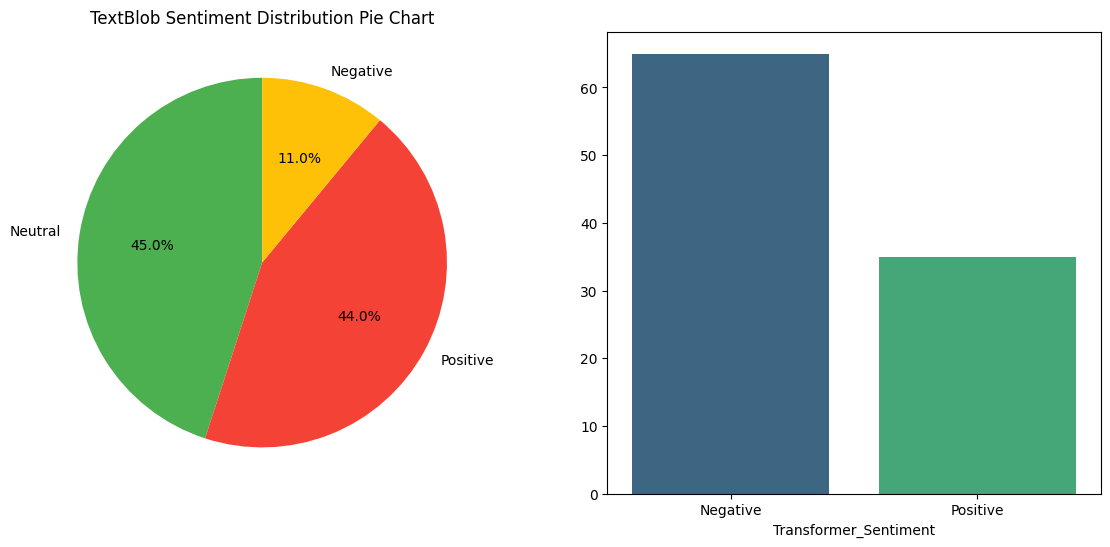

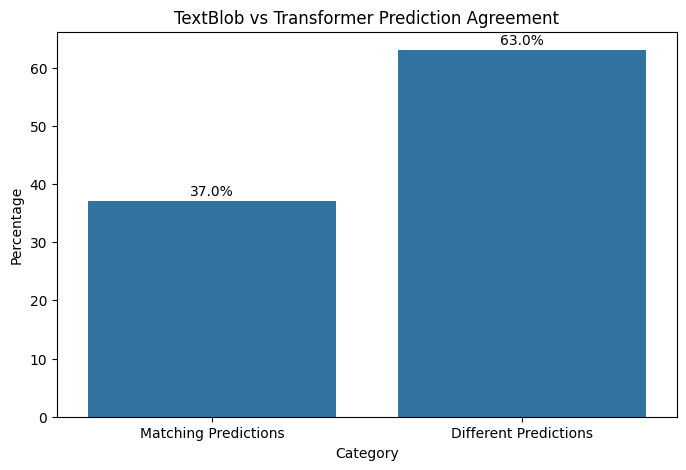

<Figure size 640x480 with 0 Axes>

In [ ]:
#Count total positive, negative, and neutral metrics
print("TextBlob Sentiment Summary Counts")
print(df['TextBlob_Sentiment'].value_counts())
print("Hugging Face Transformer Summary Counts")
print(df['Transformer_Sentiment'].value_counts())

# Create Visualizations (
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot A: TextBlob Pie Chart
tb_counts = df['TextBlob_Sentiment'].value_counts()
axes[0].pie(tb_counts, labels=tb_counts.index, autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336', '#FFC107'], startangle=90)
axes[0].set_title('TextBlob Sentiment Distribution Pie Chart')

# Subplot B: Transformer Bar Chart
hf_counts = df['Transformer_Sentiment'].value_counts()
sns.barplot(
    x=hf_counts.index,
    y=hf_counts.values,
    hue=hf_counts.index,
    palette='viridis',
    legend=False,
    ax=axes[1]
)
print("--- Hugging Face Transformer Summary Counts ---")
print(df['Transformer_Sentiment'].value_counts())
print("\n📋 --- Sentiment Comparison Table ---")

comparison = pd.crosstab(
    df['TextBlob_Sentiment'],
    df['Transformer_Sentiment']
)

print(comparison)
# === SENTIMENT MODEL COMPARISON CHART ===

agreement = (
    df['TextBlob_Sentiment'] ==
    df['Transformer_Sentiment']
).mean() * 100

disagreement = 100 - agreement

accuracy_data = pd.DataFrame({
    'Category': ['Matching Predictions', 'Different Predictions'],
    'Percentage': [agreement, disagreement]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=accuracy_data,
    x='Category',
    y='Percentage'
)

plt.title("TextBlob vs Transformer Prediction Agreement")
plt.ylabel("Percentage")

for index, row in accuracy_data.iterrows():
    plt.text(index, row['Percentage'] + 1,
             f"{row['Percentage']:.1f}%",
             ha='center')

plt.savefig(
    "prediction_agreement_chart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.tight_layout()
# Save charts as images implicitly inside notebook layout
plt.savefig(
    'sentiment_analysis_plots.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
# Show top 3 positive and negative reviews based on polarity scores
print("=== TOP 3 MOST POSITIVE REVIEWS ===")
top_positive = df.nlargest(3, 'textblob_polarity')
for idx, row in top_positive.iterrows():
    print(f"Polarity Score: {row['textblob_polarity']:.2f} | Label: {row['TextBlob_Sentiment']}")
    print(f"Review Summary: {row['review'][:250]}...\n" + "-"*50)

print("=== TOP 3 MOST NEGATIVE REVIEWS ===")
top_negative = df.nsmallest(3, 'textblob_polarity')
for idx, row in top_negative.iterrows():
    print(f"Polarity Score: {row['textblob_polarity']:.2f} | Label: {row['TextBlob_Sentiment']}")
    print(f"Review Summary: {row['review'][:250]}...\n" + "-"*50)

#Save final result to CSV and auto-download from Colab workspace
output_movie_review = 'final_movie_reviews_sentiment.csv'
df.to_csv(output_movie_review, index=False)
print(f"Saved results to '{output_movie_review}'. Downloading file now...")
files.download(output_movie_review)

=== TOP 3 MOST POSITIVE REVIEWS ===
Polarity Score: 0.48 | Label: Positive
Review Summary: I went to see Hamlet because I was in between jobs. I figured 4 hours would be great, I've been a fan of Branagh; Dead Again, Henry V. I was completely overwhelmed by the direction, acting, cinematography that this film captured. Like other reviews t...
--------------------------------------------------
Polarity Score: 0.46 | Label: Positive
Review Summary: The film is hugely enjoyable with a great cast, and excellent direction by James Eves. The movie is entertaining with a very charismatic performance from Stephanie Beecham and everyone is perfectly cast. James Eves has a good eye for casting and dire...
--------------------------------------------------
Polarity Score: 0.39 | Label: Positive
Review Summary: This is an excellent film, with an extraordinary cast and acting. I was very disappointed with the Academy Awards when this didn't get the Oscar for best film and for best actress (Woopi Go

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Interactive prompt to check a brand new custom review text snippet
print("=== LIVE MOVIE REVIEW TESTER ===")
print("Please enter or paste your movie review below, then press Enter:")
print("-" * 60)

# Moving the input line to its own row makes it much easier to use in Colab
user_input = input("> ")

if user_input.strip():
    prediction = hf_classifier(user_input)[0]
    final_label = prediction['label']
    confidence_score = prediction['score']

    print("\n🔍 --- Live Analysis Result ---")
    if final_label == "POSITIVE":
        print(f"🎉 Sentiment: POSITIVE (Confidence: {confidence_score:.2%})")
    else:
        print(f"👎 Sentiment: NEGATIVE (Confidence: {confidence_score:.2%})")
else:
    print("\n⚠️ Input field cannot be empty.")

=== LIVE MOVIE REVIEW TESTER ===
Please enter or paste your movie review below, then press Enter:
------------------------------------------------------------
> 

⚠️ Input field cannot be empty.
